In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scripts.config import PROCESSED_DIR

results = pd.read_csv(PROCESSED_DIR / 'stage2_comparison.csv')

print("Results loaded!")
print(f"Total combinations: {len(results)}\n")
print("All results:")
print(results.to_string(index=False))

Results loaded!
Total combinations: 9

All results:
          stage1        stage2  precision   recall       f1
isolation_forest random_forest   0.783883 1.000000 0.878850
isolation_forest           svm   0.918103 0.995327 0.955157
isolation_forest       xgboost   0.743056 1.000000 0.852590
             lof random_forest   0.879747 1.000000 0.936027
             lof           svm   0.920530 1.000000 0.958621
             lof       xgboost   0.908497 1.000000 0.952055
     autoencoder random_forest   0.750000 1.000000 0.857143
     autoencoder           svm   0.968750 1.000000 0.984127
     autoencoder       xgboost   0.664286 1.000000 0.798283


## 1. Best Performing Combination

In [2]:
results_sorted = results.sort_values('f1', ascending=False)

print("\nRanked by F1 Score:")
print(results_sorted[['stage1', 'stage2', 'precision', 'recall', 'f1']].to_string(index=False))

print("\nBest combination:")
best = results_sorted.iloc[0]
print(f"Stage 1: {best['stage1']}")
print(f"Stage 2: {best['stage2']}")  
print(f"Precision: {best['precision']:.4f}")
print(f"Recall: {best['recall']:.4f}")
print(f"F1 Score: {best['f1']:.4f}")


Ranked by F1 Score:
          stage1        stage2  precision   recall       f1
     autoencoder           svm   0.968750 1.000000 0.984127
             lof           svm   0.920530 1.000000 0.958621
isolation_forest           svm   0.918103 0.995327 0.955157
             lof       xgboost   0.908497 1.000000 0.952055
             lof random_forest   0.879747 1.000000 0.936027
isolation_forest random_forest   0.783883 1.000000 0.878850
     autoencoder random_forest   0.750000 1.000000 0.857143
isolation_forest       xgboost   0.743056 1.000000 0.852590
     autoencoder       xgboost   0.664286 1.000000 0.798283

Best combination:
Stage 1: autoencoder
Stage 2: svm
Precision: 0.9688
Recall: 1.0000
F1 Score: 0.9841


## 2. Performance Comparison Visualization

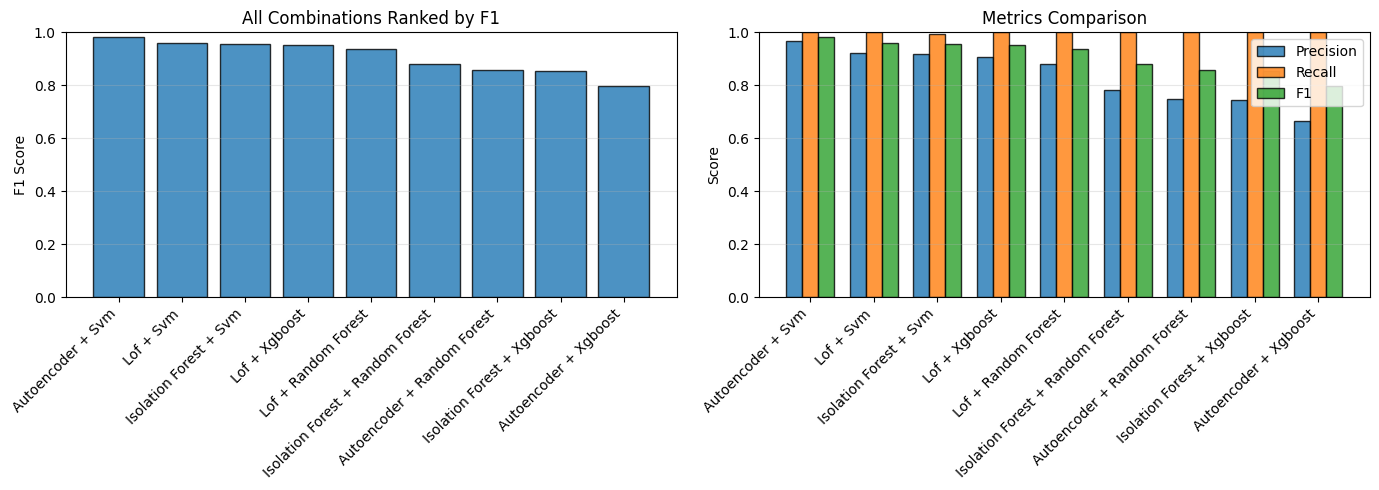

In [3]:
results_sorted = results.sort_values('f1', ascending=False)
results_sorted['combo'] = results_sorted['stage1'].str.replace('_', ' ').str.title() + ' + ' + results_sorted['stage2'].str.replace('_', ' ').str.title()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x_pos = np.arange(len(results_sorted))
ax1.bar(x_pos, results_sorted['f1'], alpha=0.8, edgecolor='black')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(results_sorted['combo'], rotation=45, ha='right')
ax1.set_ylabel('F1 Score')
ax1.set_title('All Combinations Ranked by F1')
ax1.set_ylim([0, 1])
ax1.grid(axis='y', alpha=0.3)

x_pos2 = np.arange(len(results_sorted))
width = 0.25
ax2.bar(x_pos2 - width, results_sorted['precision'], width, label='Precision', alpha=0.8, edgecolor='black')
ax2.bar(x_pos2, results_sorted['recall'], width, label='Recall', alpha=0.8, edgecolor='black')
ax2.bar(x_pos2 + width, results_sorted['f1'], width, label='F1', alpha=0.8, edgecolor='black')
ax2.set_xticks(x_pos2)
ax2.set_xticklabels(results_sorted['combo'], rotation=45, ha='right')
ax2.set_ylabel('Score')
ax2.set_title('Metrics Comparison')
ax2.legend()
ax2.set_ylim([0, 1])
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Stage 1 Model Performance


Stage 1 Model Performance (average across Stage 2 partners):
                  precision  recall      f1
stage1                                     
lof                  0.9029  1.0000  0.9489
isolation_forest     0.8150  0.9984  0.8955
autoencoder          0.7943  1.0000  0.8799


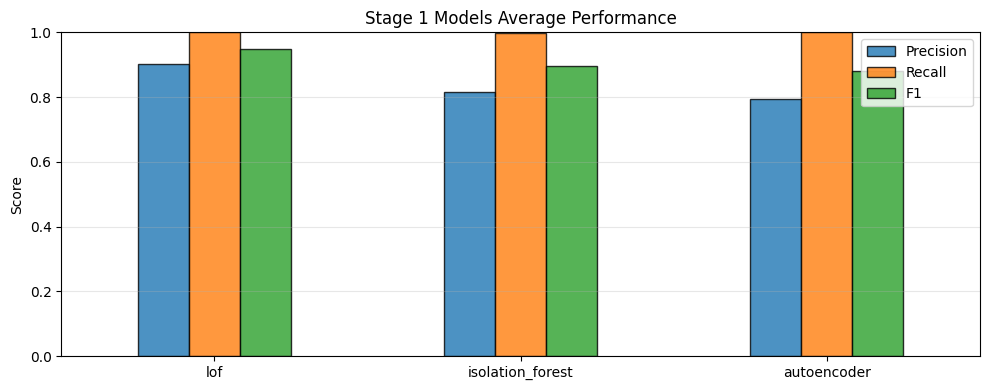

In [4]:
stage1_perf = results.groupby('stage1')[['precision', 'recall', 'f1']].mean()
stage1_perf = stage1_perf.sort_values('f1', ascending=False)

print("\nStage 1 Model Performance (average across Stage 2 partners):")
print(stage1_perf.round(4))

fig, ax = plt.subplots(figsize=(10, 4))
stage1_perf.plot(kind='bar', ax=ax, alpha=0.8, edgecolor='black')
ax.set_title('Stage 1 Models Average Performance')
ax.set_ylabel('Score')
ax.set_xlabel('')
ax.set_ylim([0, 1])
ax.legend(['Precision', 'Recall', 'F1'])
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Stage 2 Model Performance


Stage 2 Model Performance (average across Stage 1 partners):
               precision  recall      f1
stage2                                  
svm               0.9358  0.9984  0.9660
random_forest     0.8045  1.0000  0.8907
xgboost           0.7719  1.0000  0.8676


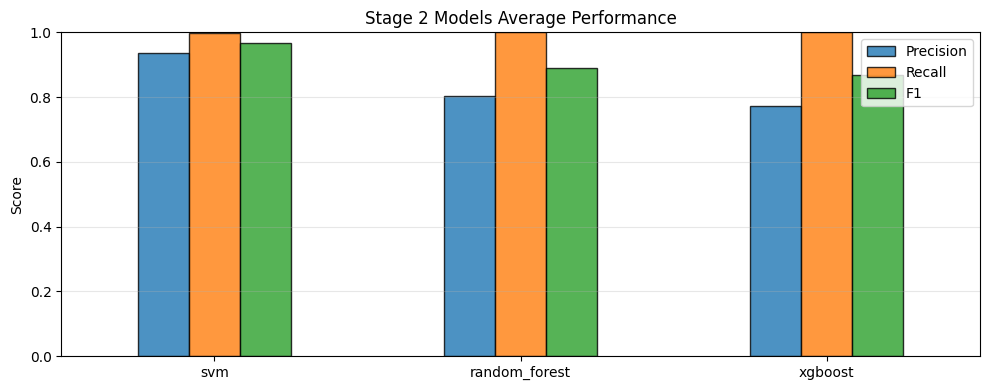

In [5]:
stage2_perf = results.groupby('stage2')[['precision', 'recall', 'f1']].mean()
stage2_perf = stage2_perf.sort_values('f1', ascending=False)

print("\nStage 2 Model Performance (average across Stage 1 partners):")
print(stage2_perf.round(4))

fig, ax = plt.subplots(figsize=(10, 4))
stage2_perf.plot(kind='bar', ax=ax, alpha=0.8, edgecolor='black')
ax.set_title('Stage 2 Models Average Performance')
ax.set_ylabel('Score')
ax.set_xlabel('')
ax.set_ylim([0, 1])
ax.legend(['Precision', 'Recall', 'F1'])
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Performance Matrix Heatmap

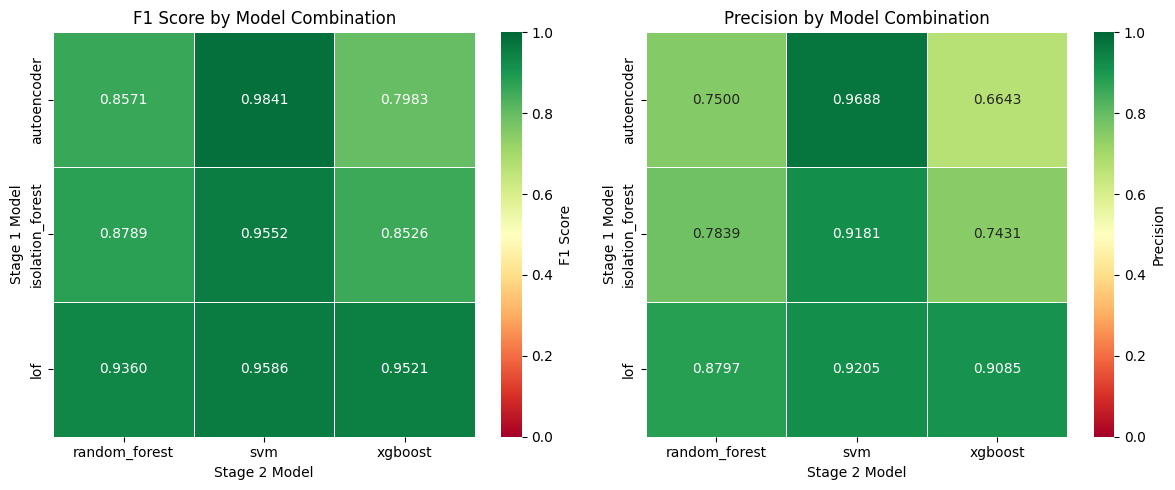

In [6]:
pivot_f1 = results.pivot_table(values='f1', index='stage1', columns='stage2')
pivot_precision = results.pivot_table(values='precision', index='stage1', columns='stage2')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(pivot_f1, annot=True, fmt='.4f', cmap='RdYlGn', vmin=0, vmax=1, ax=ax1, cbar_kws={'label': 'F1 Score'}, linewidths=0.5)
ax1.set_title('F1 Score by Model Combination')
ax1.set_xlabel('Stage 2 Model')
ax1.set_ylabel('Stage 1 Model')

sns.heatmap(pivot_precision, annot=True, fmt='.4f', cmap='RdYlGn', vmin=0, vmax=1, ax=ax2, cbar_kws={'label': 'Precision'}, linewidths=0.5)
ax2.set_title('Precision by Model Combination')
ax2.set_xlabel('Stage 2 Model')
ax2.set_ylabel('Stage 1 Model')

plt.tight_layout()
plt.show()

## 6. Summary

In [8]:
best = results.sort_values('f1', ascending=False).iloc[0]
worst = results.sort_values('f1').iloc[0]

print("Summary:")
print(f"Best combination: {best['stage1']} + {best['stage2']} with F1 = {best['f1']:.4f}")

print(f"Average F1 across all: {results['f1'].mean():.4f}")

print(f"F1 Score: {best['f1']:.4f}")
print(f"Precision: {best['precision']:.4f} (fewer false alarms)")
print(f"Recall: {best['recall']:.4f} (catches all attacks)")

Summary:
Best combination: autoencoder + svm with F1 = 0.9841
Average F1 across all: 0.9081
F1 Score: 0.9841
Precision: 0.9688 (fewer false alarms)
Recall: 1.0000 (catches all attacks)
